In [1]:
from google.colab import files

uploaded = files.upload()

Saving house-prices-advanced-regression-techniques.zip to house-prices-advanced-regression-techniques.zip


In [2]:
import os

print(os.listdir())

['.config', 'house-prices-advanced-regression-techniques.zip', 'sample_data']


In [4]:
import zipfile
import os

zip_file = "house-prices-advanced-regression-techniques.zip"
extract_folder = "house_price_data"

os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("Dataset extracted successfully.")
print(os.listdir(extract_folder))

Dataset extracted successfully.
['data_description.txt', 'test.csv', 'sample_submission.csv', 'train.csv']


In [5]:
import pandas as pd

data = pd.read_csv("house_price_data/train.csv")

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
required_columns = [
    "GrLivArea",
    "BedroomAbvGr",
    "FullBath",
    "HalfBath",
    "BsmtFullBath",
    "BsmtHalfBath",
    "SalePrice"
]

data[required_columns].head()

,GrLivArea,BedroomAbvGr,FullBath,HalfBath,BsmtFullBath,BsmtHalfBath,SalePrice
0,1710,3,2,1,1,0,208500
1,1262,3,2,0,0,1,181500
2,1786,3,2,1,1,0,223500
3,1717,3,1,0,1,0,140000
4,2198,4,2,1,1,0,250000


In [7]:
data["TotalBathrooms"] = (
    data["FullBath"]
    + 0.5 * data["HalfBath"]
    + data["BsmtFullBath"]
    + 0.5 * data["BsmtHalfBath"]
)

data[
    ["GrLivArea", "BedroomAbvGr", "TotalBathrooms", "SalePrice"]
].head()

,GrLivArea,BedroomAbvGr,TotalBathrooms,SalePrice
0,1710,3,3.5,208500
1,1262,3,2.5,181500
2,1786,3,3.5,223500
3,1717,3,2.0,140000
4,2198,4,3.5,250000


In [8]:
features = ["GrLivArea", "BedroomAbvGr", "TotalBathrooms"]

X = data[features]
y = data["SalePrice"]

print("Input shape:", X.shape)
print("Target shape:", y.shape)

print("\nMissing values in features:")
print(X.isnull().sum())

print("\nMissing values in target:")
print(y.isnull().sum())

Input shape: (1460, 3)
Target shape: (1460,)

Missing values in features:
GrLivArea         0
BedroomAbvGr      0
TotalBathrooms    0
dtype: int64

Missing values in target:
0


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 1168
Testing records: 292


In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [11]:
y_pred = model.predict(X_test)

print("First 10 predicted prices:")
print(y_pred[:10])

First 10 predicted prices:
[113611.53310361 321075.73322926 117980.40627361 185120.41397544
 234377.60269572 133726.4522589  212573.04502953 180519.24185596
 133726.4522589  144377.41273318]


In [12]:
import pandas as pd

results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

results.head(10)

,Actual Price,Predicted Price
0,154500,113611.533104
1,325000,321075.733229
2,115000,117980.406274
3,159000,185120.413975
4,315500,234377.602696
5,75500,133726.452259
6,311500,212573.045030
7,146000,180519.241856
8,84500,133726.452259
9,135500,144377.412733


In [13]:
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("Mean Squared Error:", round(mse, 2))
print("Root Mean Squared Error:", round(rmse, 2))
print("R² Score:", round(r2, 4))

Mean Absolute Error: 34395.8
Mean Squared Error: 2623753007.35
Root Mean Squared Error: 51222.58
R² Score: 0.6579


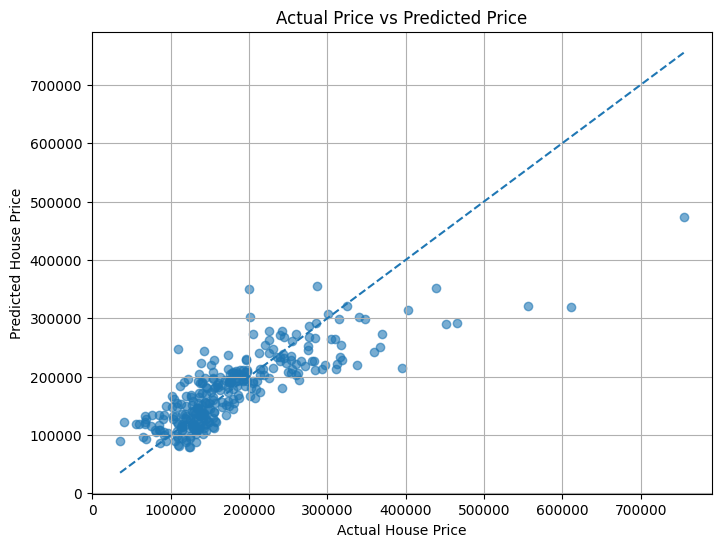

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)

minimum_price = min(y_test.min(), y_pred.min())
maximum_price = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum_price, maximum_price],
    [minimum_price, maximum_price],
    linestyle="--"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual Price vs Predicted Price")
plt.grid(True)
plt.show()

In [16]:
new_house = pd.DataFrame({
    "GrLivArea": [2000],
    "BedroomAbvGr": [3],
    "TotalBathrooms": [2.5]
})

predicted_price = model.predict(new_house)[0]

print("Predicted House Price: ${:,.2f}".format(predicted_price))

Predicted House Price: $232,016.59


In [17]:
results.to_csv("house_price_predictions.csv", index=False)

print("Results saved successfully.")

Results saved successfully.


In [18]:
from google.colab import files

files.download("house_price_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>